# 🇵🇰 Pakistani Currency Detection using YOLOv8

## Objective:
Train a YOLOv8 model to detect Pakistani currency notes in real time using object detection.

We will:
- Download dataset from Roboflow
- Train YOLOv8 model
- Test predictions
- Save best model for deployment

In [1]:
# Install YOLO + Roboflow
!pip install ultralytics roboflow

  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.8 MB 4.9 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.8 MB 7.0 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/38.8 MB 7.0 MB/s eta 0:00:05
   ---- ----------------------------------- 4.7/38.8 MB 5.1 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/38.8 MB 5.1 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/38.8 MB 5.1 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/38.8 MB 3.7 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/38.8 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/38.8 MB 4.2 MB/s eta 0:00:08
   --------- -----


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Saeer Jan\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
# Import required libraries

from roboflow import Roboflow
from ultralytics import YOLO

import os

ModuleNotFoundError: No module named 'roboflow'

In [4]:
# ===============================
# CONNECTING ROBOFLOW DATASET
# ===============================
%pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="DrMInrTDpSwQYduMzhxK")
project = rf.workspace("saeers-workspace").project("pakistani-currency-note-data-nd27h")
dataset = project.version(2).download("yolov8")

print("Dataset downloaded successfully!")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached roboflow-1.3.8-py3-none-any.whl.metadata (11 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached roboflow-1.3.8-py3-none-any.whl (207 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? 


Extracting Dataset Version Zip to pakistani-currency-note-data-2 in yolov8:: 100%|██████████| 8017/8017 [00:15<00:00, 507.98it/s] 


Dataset downloaded successfully!


In [5]:
# =========================
# CHECK DATASET LOCATION
# =========================

import os

print("Dataset path:", dataset.location)

# List files to confirm structure
os.listdir(dataset.location)

Dataset path: d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2


['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

In [6]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model (small version for balance)
model = YOLO("yolov8n.pt")

In [7]:
# =========================
# TRAIN YOLO MODEL
# =========================

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=-1,               # 🚀 Auto-adjusts to the maximum size your GPU can hold (faster than 16)
    cache="disk",           # 🚀 Caches images to local SSD to eliminate slow disk reading bottlenecks
    workers=4,              # 🚀 Uses parallel CPU threads to load images quickly into the GPU
    patience=5,             # 🚀 Early stopping if the model stops improving
    name="currency_detection_model"
)


New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i5-8265U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

KeyboardInterrupt: 

In [14]:
# Check training output folder
!ls runs/detect/

currency_detection_model  predict


In [8]:
# =========================
# TEST ON SAMPLE IMAGE
# =========================

results = model.predict(
    source=f"{dataset.location}/test/images",
    conf=0.5,
    save=True
)

print("Prediction complete!")


image 1/403 d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\test\images\000_17679021L_jpg.rf.13987a62059dd789aa6d27dc0a2be613.jpg: 352x640 (no detections), 141.4ms
image 2/403 d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\test\images\10_jpg.rf.994d500c707d86af267495fc39acf3f3.jpg: 640x640 (no detections), 186.2ms
image 3/403 d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\test\images\15_jpg.rf.9e16a486e7122934b08e5d491b74954a.jpg: 256x640 (no detections), 134.8ms
image 4/403 d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\test\images\50286942_2575102786045753_2801929388512247808_n_jpg.rf.60c96b9c00765d8c19cb50486b39d713.jpg: 640x480 (no detections), 147.4ms
image 5/403 d:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\test\images\50542021_520489571770648_2050

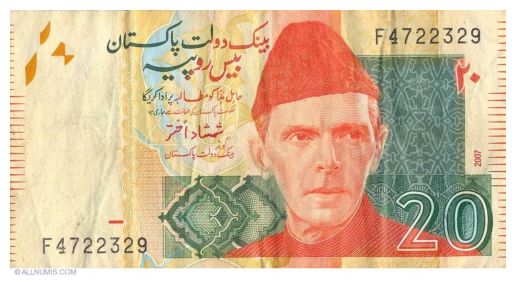

In [9]:
import matplotlib.pyplot as plt
import cv2

img_path = results[0].path
img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
# Model evaluation metrics
model.val()

Ultralytics 8.4.48  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i5-8265U 1.60GHz)

WARNING Dataset 'coco.yaml' images not found, missing path 'C:\Users\datasets\coco\val2017.txt'


PermissionError: [WinError 5] Access is denied: 'C:\\Users\\datasets'

In [17]:
# ==========================================
# DOWNLOAD BEST TRAINED YOLO MODEL
# ==========================================

from google.colab import files

# Path where YOLO saves best model
model_path = "runs/detect/currency_detection_model/weights/best.pt"

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from ultralytics import YOLO

# Load your trained model
model = YOLO(r"C:\Users\Saeer Jan\Downloads\best.pt")

# Run validation with dataset
results = model.val(
    data=f"{dataset.location}/data.yaml",
    imgsz=640,
    batch=16,
    conf=0.25

)

Ultralytics 8.4.48  Python-3.14.0 torch-2.11.0+cpu CPU (Intel Core i5-8265U 1.60GHz)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 104.226.2 MB/s, size: 40.5 KB)
val: Scanning D:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\valid\labels... 802 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 802/802 592.2it/s 1.4s0.1s
val: New cache created: D:\Langchain\computer_vision\Pakistani_Currency_YOLO\notebooks\pakistani-currency-note-data-2\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 2.3s/it 1:562.0sss
                   all        802       3898       0.88      0.902      0.877      0.465
                    10        108        544      0.938      0.914       0.91      0.517
                   100         90        327      0.798      0.783      0.716      0.251
            

In [15]:
%pip install --upgrade matplotlib opencv-python
import matplotlib.pyplot as plt
import cv2
img = cv2.imread("runs/detect/val/confusion_matrix_normalized.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")
plt.show()

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.3 MB 2.1 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.7 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.3 MB 3.1 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 3.2 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 3.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 3.6 MB/s eta 0:00:01
   --------------------------------- ------ 7.1/8.3 MB 3.5 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 3.6 MB/s eta 0:00:01
   ------------------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\saeer jan\\appdata\\local\\programs\\python\\python314\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp314-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [19]:
# ==========================================
# DOWNLOAD NOTEBOOK FILE
# ==========================================

from google.colab import files
files.download("/content/yolo_training.ipynb")

FileNotFoundError: Cannot find file: /content/yolo_training.ipynb